E-5: Regressione logistica su due gaussiane ben separabili, addestrata con cross-entropy invece dell'errore quadratico. Continui ad addestrare molto oltre il punto in cui l'accuratezza è già al
100%, e osservi la norma dei pesi

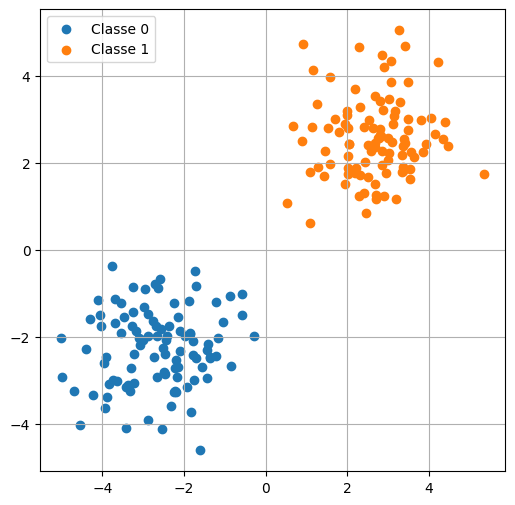

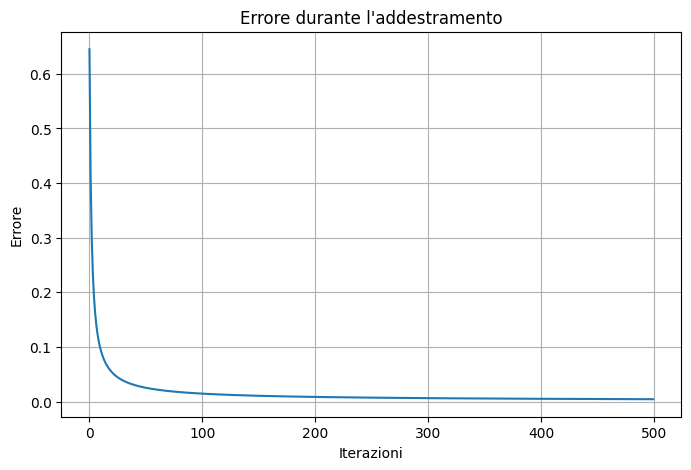

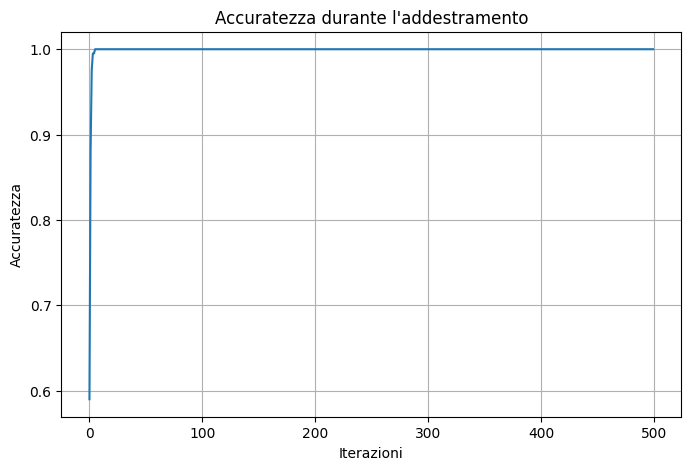

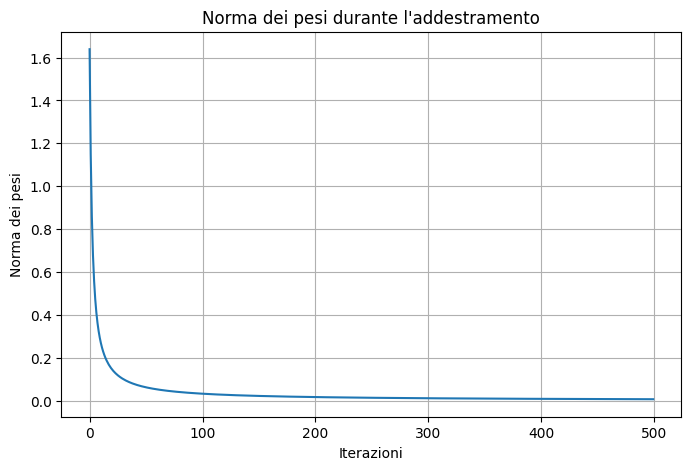

In [ ]:
import torch
import matplotlib.pyplot as plt

#generazione dei dati
torch.manual_seed(42)

N = 100

X0 = torch.randn(N, 2) + torch.tensor([-2.5, -2.5])
X1 = torch.randn(N, 2) + torch.tensor([2.5, 2.5])

x = torch.cat([X0, X1], dim = 0)

y = torch.cat([
    torch.zeros(N),
    torch.ones(N)
]).unsqueeze(1)

#visualizzazione dei dati
plt.figure(figsize=(6,6))
plt.scatter(X0[:, 0], X0[:, 1], label="Classe 0")
plt.scatter(X1[:, 0], X1[:, 1], label="Classe 1")
plt.legend()
plt.grid(True)
plt.show()

#Regressione logistica

model = torch.nn.Linear(2,1)

errore_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

#generazione del gradiente
iterazioni = 500
errori = []
accuratezze = []
norme = []

for i in range(iterazioni):

  optimizer.zero_grad()
  predizione_y = model(x)
  errore = errore_fn(predizione_y, y)
  errore.backward()
  optimizer.step()

  errori.append(errore.item())

  with torch.no_grad():

    probabilita = torch.sigmoid(predizione_y)
    predizione = (probabilita > 0.5).float()
    accuratezza = (predizione == y).float().mean()
    accuratezze.append(accuratezza.item())

    #calcolo i pesi
    norma = torch.norm(model.weight.grad)
    norme.append(norma.item())

#grafico dell'errore
plt.figure(figsize=(8,5))
plt.plot(errori)
plt.xlabel("Iterazioni")
plt.ylabel("Errore")
plt.title("Errore durante l'addestramento")
plt.grid(True)
plt.show()

#grafico accuratezza
plt.figure(figsize=(8,5))
plt.plot(accuratezze)
plt.xlabel("Iterazioni")
plt.ylabel("Accuratezza")
plt.title("Accuratezza durante l'addestramento")
plt.grid(True)
plt.show()

#grafico della norma dei pesi
plt.figure(figsize=(8,5))
plt.plot(norme)
plt.xlabel("Iterazioni")
plt.ylabel("Norma dei pesi")
plt.title("Norma dei pesi durante l'addestramento")
plt.grid(True)
plt.show()


Q-4: Perché nella cross-entropy compare il logaritmo? Cosa va storto usando l'errore quadratico sulle probabilità? Guardi la forma del gradiente geometrica nei due casi.


Il fatto che nella cross-entrompy compaia il lograitmo deriva dalla sua derivata. la derivata del logaritmo è 1/p mentre per l'errore quadratico è
2(p-1)p(1-p). Nel caso di un modello che è molto sicuro ma che presenta ancora un errore minimo, il logaritmo permette di notarlo in modo molto evidente poiché il gradiente in questo caso amplifica radicalmente la probabilità a differenza del errore quadratico medio in cui si annullerebbe.

Q-5: Supponiamo che un probe ottiene AUC 0,95 per «protocollo» e 0,55 per «durata del flusso». Sono lecite entrambe queste conclusioni:
(a) la rappresentazione contiene il protocollo; (b) la rappresentazione non contiene la durata? Una delle due è illecita: quale e perché?

Si può considerare illecita la seconda opzione poiché il probe fornisce informazioni relative alla possibilità di recuperare una cera informazione nel modello, non se sia effettivamente presente o meno. Quindi il probe non definisce la presenza o meno di un'informazione, ma solo la capacità di trovarla o meno. Per questo motivo, la prima opzione è coerente con il probe, mentre la seconda è sbagliata perché non è detto che la rappresentazione non contenga la durata, ma solo che questa non può essere recuperata.

Q-6: Se il collasso è un fenomeno del training set, perché dovrebbe preoccupare qualcuno? Costruisca l'argomento per cui è un problema
pratico e non una curiosità geometrica.

Il Neural Collapse compare nell'ultima fase dell'addestramento quando, dopo aver già raggiunto il 100% o quasi di accuratezza sull'errore l'addestramento prosegue. Durante questa fase si verificano alcuni fenomeni, tra cui NC1 e NC2. NC1 comporta la perdita della variabilità all'interno della classe, quindi esempi appartenenti alla stessa classe tendono a concentrarsi attorno alla propria media. NC2 provoca un disposizione della media delle diverse classi secondo una struttura geometrica regolare e quindi avviene una separazione delle classi  A causa di questi due fenomeni quindi il collasso diventa un problema pratico poiché causa una perdita di capacità rappresentazionale e della varianza intra-classe, mantenendo una forte separazione tra le classi.